## 1. Installation

In [10]:
!pip install -q easyocr
from importlib.metadata import version
print("easyocr version :", version("easyocr"))

easyocr version : 1.7.2


## 2. Verifier le dataset Kaggle

Sur Kaggle, les fichiers d'un dataset ajoute au notebook sont montes en lecture seule sous `/kaggle/input/<nom-du-dataset>/`. On liste le contenu pour confirmer le chemin exact avant de continuer (utile si le PDF est dans un sous-dossier).

In [11]:
import os

# Etape 1 : lister tous les datasets disponibles sous /kaggle/input
print("Datasets disponibles dans /kaggle/input :")
for name in os.listdir("/kaggle/input"):
    print(" -", name)

Datasets disponibles dans /kaggle/input :
 - datasets


In [12]:
# Etape 2 : exploration recursive complete pour trouver tous les PDF,
# quelle que soit la profondeur des sous-dossiers
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.lower().endswith(".pdf"):
            print(os.path.join(root, f))

/kaggle/input/datasets/hasnaasaadi/my-dataset-test/loan_0001.pdf


## 3. Configuration des parametres de lecture

Les options principales se reglent a la creation du `Reader` (langues, GPU) puis a l'appel de `readtext` (seuils de detection).

In [13]:
import easyocr

# --- Langues ---
# Liste des codes langues a reconnaitre simultanement
# fr = francais, en = anglais, de = allemand (langues latines, compatibles ensemble sous EasyOCR)
# Voir la liste complete : https://www.jaided.ai/easyocr/
LANGUAGES = ["fr", "en", "de"]

# --- GPU ---
# gpu=True acceleration si un GPU est disponible sur le notebook (Settings > Accelerator sur Kaggle)
# Mettre gpu=False si aucun GPU n'est active, sinon le chargement echoue ou retombe sur CPU.
USE_GPU = True

reader = easyocr.Reader(LANGUAGES, gpu=USE_GPU)
print("Reader pret.")

Reader pret.


## 4. Lecture du PDF et conversion en images

Chemin adapte a Kaggle : `/kaggle/input/<dataset>/...` pour la lecture (lecture seule).

EasyOCR travaille sur des images. Chaque page du PDF est donc convertie en image avec `pdf2image`, qui s'appuie sur le binaire `poppler` (installe via `apt-get` dans la cellule suivante, car absent par defaut de certaines images Kaggle) avant de lancer l'OCR.

In [14]:
# Adapte le nom de fichier si besoin, d'apres la sortie de la cellule 2
DATASET_DIR = "/kaggle/input/datasets/hasnaasaadi/my-dataset-test"
PDF_PATH = os.path.join(DATASET_DIR, "loan_0001.pdf")

OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# pdf2image s'appuie sur le binaire "poppler" (pdfinfo, pdftoppm), absent par defaut
# de certaines images Kaggle -> on l'installe via apt avant d'utiliser pdf2image.
!apt-get update -qq && apt-get install -y -qq poppler-utils
!pip install -q pdf2image

from pdf2image import convert_from_path

pages = convert_from_path(PDF_PATH, dpi=200)
image_paths = []
for i, page in enumerate(pages):
    img_path = os.path.join(OUTPUT_DIR, f"page_{i+1}.png")
    page.save(img_path, "PNG")
    image_paths.append(img_path)

print("Pages converties en images :", image_paths)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
(Reading database ... 125186 files and directories currently installed.)
Preparing to unpack .../libpoppler-private-dev_22.02.0-2ubuntu0.13_amd64.deb ...
Unpacking libpoppler-private-dev:amd64 (22.02.0-2ubuntu0.13) over (22.02.0-2ubuntu0.12) ...
Preparing to unpack .../libpoppler-dev_22.02.0-2ubuntu0.13_amd64.deb ...
Unpacking libpoppler-dev:amd64 (22.02.0-2ubuntu0.13) over (22.02.0-2ubuntu0.12) ...
Preparing to unpack .../libpoppler118_22.02.0-2ubuntu0.13_amd64.deb ...
Unpacking libpoppler118:amd64 (22.02.0-2ubuntu0.13) over (22.02.0-2ubuntu0.12) ...
Selecting previously unselected package poppler-utils.
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.13_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.13) ...
Setting up libpoppler118:amd64 (22.02.0-2ubuntu0.13) ...
Setting up poppler-

## 5. Execution de l'OCR

`readtext` renvoie, pour chaque zone de texte detectee, un triplet `(bbox, texte, score_confiance)`.

In [15]:
all_results = []  # liste de dicts : page, bbox, texte, confiance

for page_num, img_path in enumerate(image_paths, start=1):
    results = reader.readtext(img_path)
    print(f"Page {page_num} : {len(results)} zones de texte detectees")
    for bbox, text, conf in results:
        all_results.append({
            "page": page_num,
            "bbox": bbox,
            "text": text,
            "confidence": conf,
        })

print("\nTotal zones detectees :", len(all_results))

Page 1 : 58 zones de texte detectees
Page 2 : 3 zones de texte detectees

Total zones detectees : 61


## 6. Export du contenu

Le Markdown est le plus lisible, le JSON (avec positions et scores) est le plus complet pour un traitement automatique en aval — meme logique que `export_to_markdown()` / `export_to_dict()` sous Docling.

In [16]:
# Construction du Markdown, page par page (comme doc.export_to_markdown() avec Docling)
md_text = ""
current_page = None
for r in all_results:
    if r["page"] != current_page:
        current_page = r["page"]
        md_text += f"\n\n## Page {current_page}\n\n"
    md_text += r["text"] + "\n"

print(md_text)



## Page 1

Loan Application for a Commercial Real Estate
Loan
Company Profile
1 .
Applicant
Company Name
Söding GmbH & Co. KGaA UG
Legal Form
Limited Partnership (KG)
Date of Incorporation
01/12/2006
Business Address
Falk-Textor-Weg 160, 86608 Gransee; Germany
Commercial Register Number
Court
HRB 977141
Gransee Local Court
VAT ID
Tax Number
DE681242882
2. Financial Request
Property Description
Type of Property
Office and Commercial Building
Property Name
Werden Center Gransee
Adress
Laszlo-Hiller-Allee 29, 79030 Gransee; Germany
Purchase Price
Construction Costs
€1,337,000
Desired Financing Amount
€944,000
Purpose of Use
Modernization
Equity Contribution
€393,000
Year of Construction
1990
Total Area
3,133 m?
3. Financing Proposal
Desired Loan Amount
€944,000
Term
25 years
Preferred Installment Amount
100 per month
Interest Rate
Variable
Early Repayment Desired?
[Jyes [x] no
Public Subsidies Applied For?
[x] yes [ ] no
4. Declaration & Signature
hereby confirm the accuracy and complet

In [17]:
# Sauvegarde en Markdown dans /kaggle/working (seul dossier ecriture autorisee sur Kaggle)
md_out_path = os.path.join(OUTPUT_DIR, "loan_0001_easyocr.md")

with open(md_out_path, "w", encoding="utf-8") as f:
    f.write(md_text)

print("Sauvegarde OK :", md_out_path)

Sauvegarde OK : /kaggle/working/loan_0001_easyocr.md


In [18]:
# JSON complet (texte + positions + confiance), utile pour extraire des champs automatiquement
import json

# bbox est une liste de 4 points (numpy int32) -> conversion en liste de listes d'int pour le JSON
json_ready = [
    {
        "page": r["page"],
        "text": r["text"],
        "confidence": float(r["confidence"]),
        "bbox": [[int(x), int(y)] for x, y in r["bbox"]],
    }
    for r in all_results
]

json_out_path = os.path.join(OUTPUT_DIR, "loan_0001_easyocr.json")
with open(json_out_path, "w", encoding="utf-8") as f:
    json.dump(json_ready, f, ensure_ascii=False, indent=2)

print("JSON sauvegarde :", json_out_path)

JSON sauvegarde : /kaggle/working/loan_0001_easyocr.json


## 7. Parcourir les elements avec leurs positions (bounding boxes)

Chaque zone detectee a un texte, un score de confiance et des coordonnees sur la page. Utile pour relier une valeur extraite a son emplacement physique.

In [19]:
for r in all_results:
    print(f"[page {r['page']}] conf {r['confidence']:.2f} | bbox {r['bbox']}")
    print("   ", r["text"][:90])

[page 1] conf 0.80 | bbox [[np.int32(156), np.int32(161)], [np.int32(1402), np.int32(161)], [np.int32(1402), np.int32(237)], [np.int32(156), np.int32(237)]]
    Loan Application for a Commercial Real Estate
[page 1] conf 1.00 | bbox [[np.int32(157), np.int32(231)], [np.int32(297), np.int32(231)], [np.int32(297), np.int32(291)], [np.int32(157), np.int32(291)]]
    Loan
[page 1] conf 0.75 | bbox [[np.int32(329), np.int32(225)], [np.int32(793), np.int32(225)], [np.int32(793), np.int32(309)], [np.int32(329), np.int32(309)]]
    Company Profile
[page 1] conf 0.70 | bbox [[np.int32(158), np.int32(372)], [np.int32(190), np.int32(372)], [np.int32(190), np.int32(402)], [np.int32(158), np.int32(402)]]
    1 .
[page 1] conf 0.99 | bbox [[np.int32(191), np.int32(362)], [np.int32(354), np.int32(362)], [np.int32(354), np.int32(413)], [np.int32(191), np.int32(413)]]
    Applicant
[page 1] conf 1.00 | bbox [[np.int32(169), np.int32(444)], [np.int32(359), np.int32(444)], [np.int32(359), np.int32(483)],

## 8. Visualiser les detections sur l'image

Utile pour verifier visuellement que l'OCR detecte bien les bonnes zones (par exemple les cases d'un formulaire de credit).

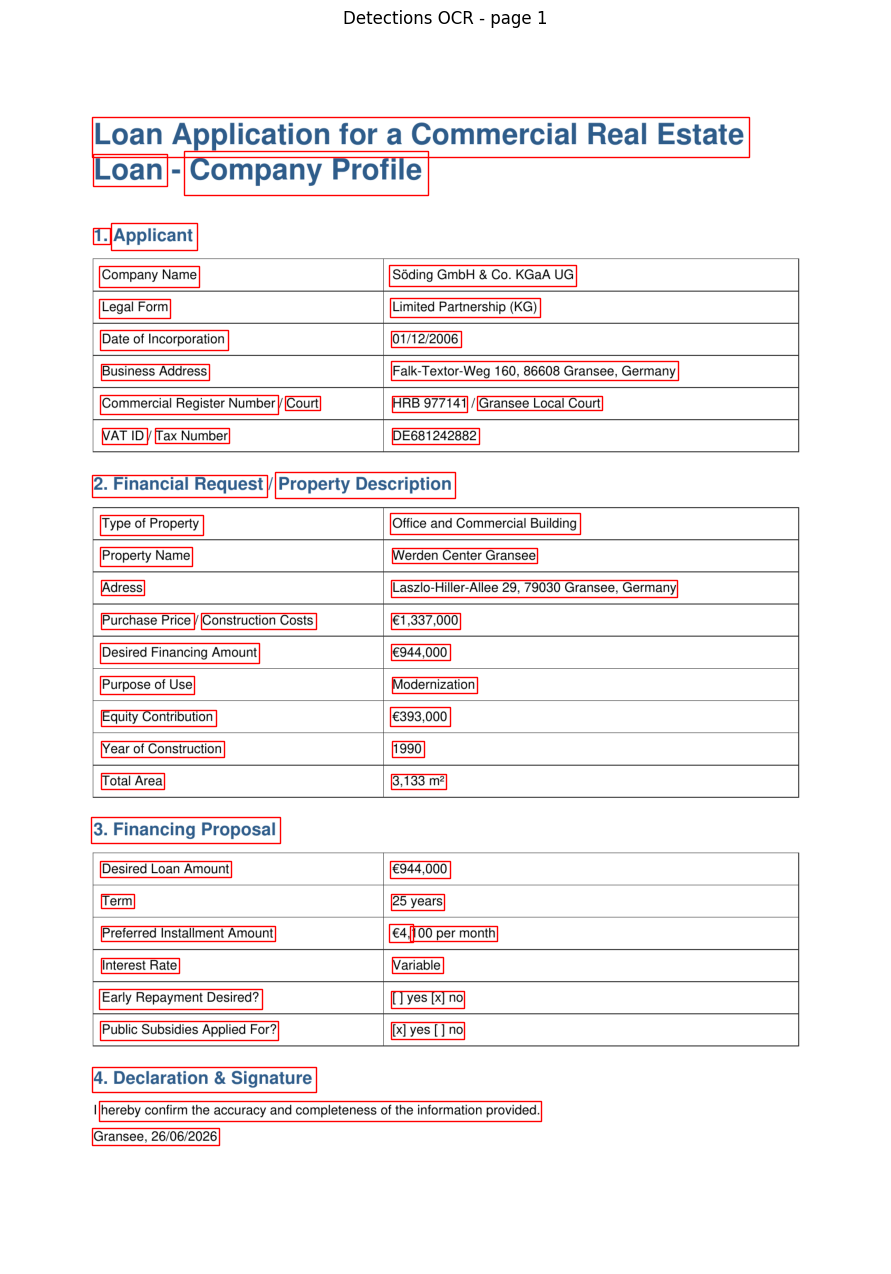

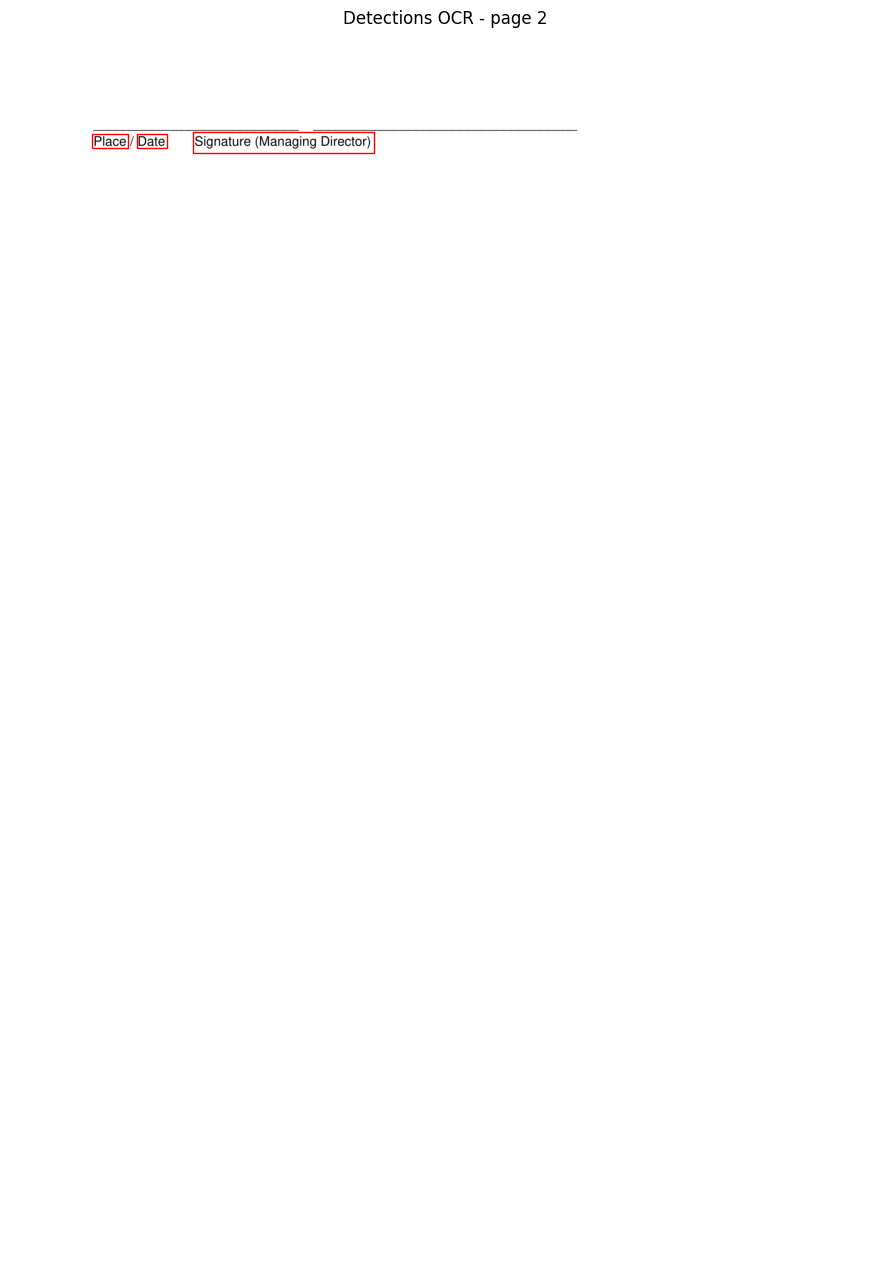

In [25]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Affiche toutes les pages, une a une
for page_num, img_path in enumerate(image_paths, start=1):
    img = Image.open(img_path)

    fig, ax = plt.subplots(figsize=(12, 16))
    ax.imshow(img)

    for r in all_results:
        if r["page"] != page_num:
            continue
        bbox = r["bbox"]
        xs = [p[0] for p in bbox]
        ys = [p[1] for p in bbox]
        x0, y0 = min(xs), min(ys)
        w, h = max(xs) - x0, max(ys) - y0
        rect = patches.Rectangle((x0, y0), w, h, linewidth=1, edgecolor="red", facecolor="none")
        ax.add_patch(rect)

    ax.set_title(f"Detections OCR - page {page_num}")
    ax.axis("off")
    plt.show()

## 9. Recuperer les resultats sous forme de tableau

Pratique pour filtrer, trier ou croiser les zones detectees (par exemple ne garder que les textes avec une confiance elevee).

## Resume des chemins Kaggle

- Lecture (input, lecture seule) : `/kaggle/input/<dataset>/...`
- Ecriture (output) : `/kaggle/working/...` -> c'est ce dossier qui apparait ensuite dans l'onglet "Output" du notebook Kaggle une fois execute/commit

## Resume des parametres principaux

- `LANGUAGES = ["fr", "en", "de"]` : francais, anglais, allemand reconnus simultanement par le modele
- `USE_GPU = True` : a mettre sur `False` si aucun accelerateur GPU n'est active sur le notebook Kaggle
- Les PDF sont convertis en images page par page (`pdf2image`) avant l'OCR, car EasyOCR ne lit que des images
- Sorties utiles : `loan_0001_easyocr.md` (texte), `loan_0001_easyocr.json` (texte + bbox + confiance), `df` (pandas)